---
title: "Practice Activity 2-2: Wrangling and Summarizing Data"
format:
  html:
    embed-resources: true
---

# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [3]:
df_titanic["type"] = "crew"
df_titanic.loc[df_titanic["class"].isin(["1st", "2nd", "3rd"]), "type"] = "passenger"
df_titanic[["class", "type"]]

,class,type
0,3rd,passenger
1,3rd,passenger
2,3rd,passenger
3,3rd,passenger
4,3rd,passenger
...,...,...
2202,deck crew,crew
2203,victualling crew,crew
2204,engineering crew,crew
2205,restaurant staff,crew


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [4]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [5]:
print(df_titanic["survived"].dtype)
df_titanic["survived"].mean()

int64


np.float64(0.3221567739012234)

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [6]:
pd.crosstab(df_titanic["survived"], df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [7]:
df_titanic.groupby("type")["survived"].mean()

type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

Answer: Passengers had a higher survival rate than crew members.

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [8]:
df_titanic.groupby(["gender", "type"])["survived"].mean()

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

Answer: For males, crew members had a higher survival rate than passengers. For females, crew members also had a higher survival rate.

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [9]:
df_titanic.groupby("type")["gender"].value_counts(normalize=True)

type       gender
crew       male      0.974157
           female    0.025843
passenger  male      0.646166
           female    0.353834
Name: proportion, dtype: float64

Answer: Passengers had a higher overall survival rate, but crew members had a higher survival rate within both males and females. This reversal occurs because the two groups had different gender compositions. Females had much higher survival rates and made up 35.38% of passengers but only 2.58% of crew members. This difference explains why passengers had a higher overall survival rate despite having lower survival rates within each gender.

## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [10]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

Answer: The observational unit is the institution. I would guess that Median Earnings is calculated by taking the median of the earnings of former students who attended each institution.

2\. Write code to find the California Polytechnic row in the data set!

In [11]:
df_college.loc[df_college["Institution"].str.contains("California Polytechnic", na=False)]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [12]:
has_earnings = df_college["Median Earnings"].notna()
df_college_clean = df_college.loc[has_earnings].copy()
df_college_clean

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0


4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [13]:
df_college_clean["Median Earnings"].describe()

count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

In [14]:
from plotnine import ggplot, aes, geom_histogram

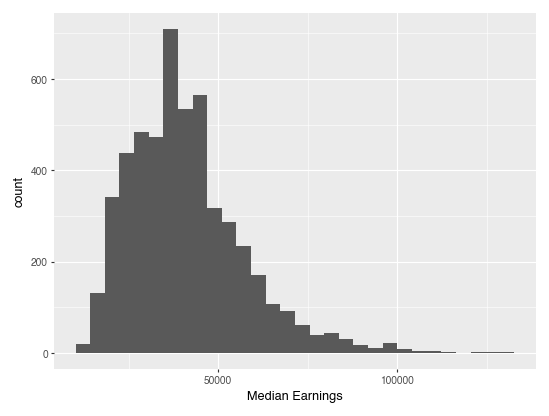

In [15]:
ggplot(df_college_clean, aes(x="Median Earnings")) + geom_histogram(bins=30)

Answer: The mean is greater than the median. The histogram shows a right-skewed distribution: a small number of institutions have particularly high median earnings, pulling the mean upward. The median is less affected by these high values.

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

In [16]:
import numpy as np

In [17]:
df_college_clean["Log Earnings"] = np.log(df_college_clean["Median Earnings"])

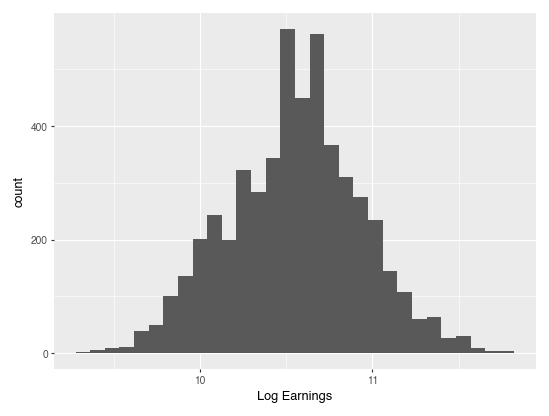

In [18]:
ggplot(df_college_clean, aes(x="Log Earnings")) + geom_histogram(bins=30)

Answer: The histogram of log earnings is more symmetric and approximately bell-shaped, while the original earnings histogram is right-skewed. Taking the log compresses the high earnings values and reduces the long right tail.

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [19]:
df_college_clean["weight"] = df_college_clean["Undergraduates"] / df_college_clean["Undergraduates"].sum()

In [20]:
(df_college_clean["weight"] * df_college_clean["Median Earnings"]).sum()

np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

In [21]:
import matplotlib.pyplot as plt

State
MA    56633.768519
VT    53040.230769
RI    52605.947368
DC    51325.470588
CT    50771.413793
NH    49322.333333
NY    48752.694352
WA    47733.266667
PA    47607.290210
MN    45855.938776
NJ    44964.081081
CA    44461.812371
MD    44454.342857
NE    43776.868421
AK    43604.500000
WI    43417.909091
ME    43400.032258
IN    43311.268519
IL    42443.338624
HI    42162.437500
OR    41934.816667
IA    41809.521127
VA    41803.976744
MO    41702.425197
CO    41578.523077
KS    41244.690141
NV    41184.741935
SD    41136.608696
AZ    40854.298851
DE    40319.153846
OH    40115.951613
ND    39603.080000
VI    39307.000000
WY    38966.300000
GA    38845.460526
AL    38225.338028
TX    38074.490683
MI    37855.232394
MT    37653.480000
NC    37178.948387
NM    36994.588235
TN    36866.411290
SC    36446.682927
FL    36162.099668
UT    35862.604651
WV    35782.507937
OK    35564.678161
KY    35171.828571
MH    34483.000000
LA    34087.642857
AR    32972.202703
ID    32823.666667
MS    

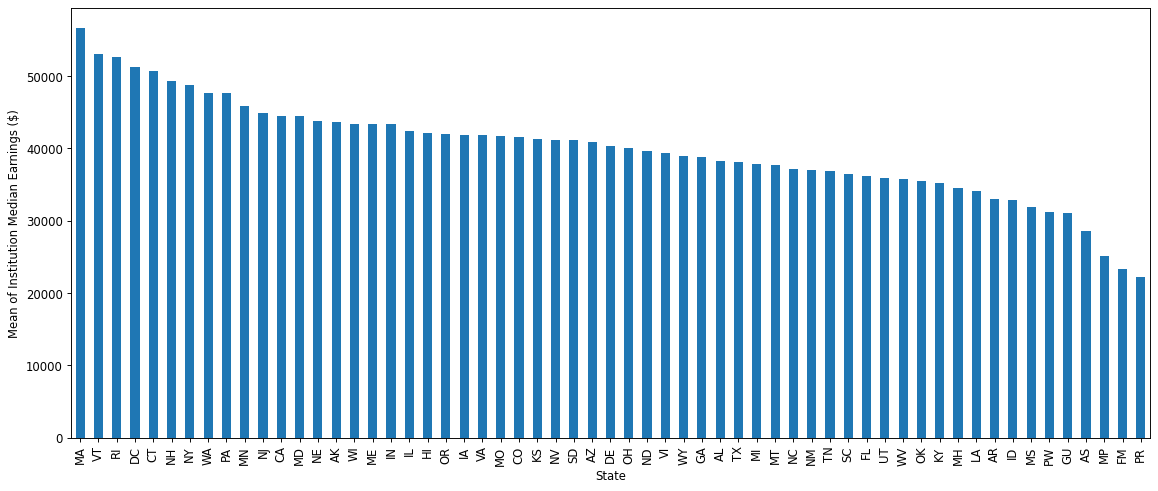

In [22]:
state_mean = df_college_clean.groupby("State")["Median Earnings"].mean().sort_values(ascending=False)
display(state_mean)

state_mean.plot.bar(figsize=(14, 6))
plt.xlabel("State")
plt.ylabel("Mean of Institution Median Earnings ($)")
plt.tight_layout()
plt.show()

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

<Axes: xlabel='State', ylabel='Weighted Mean Earnings ($)'>

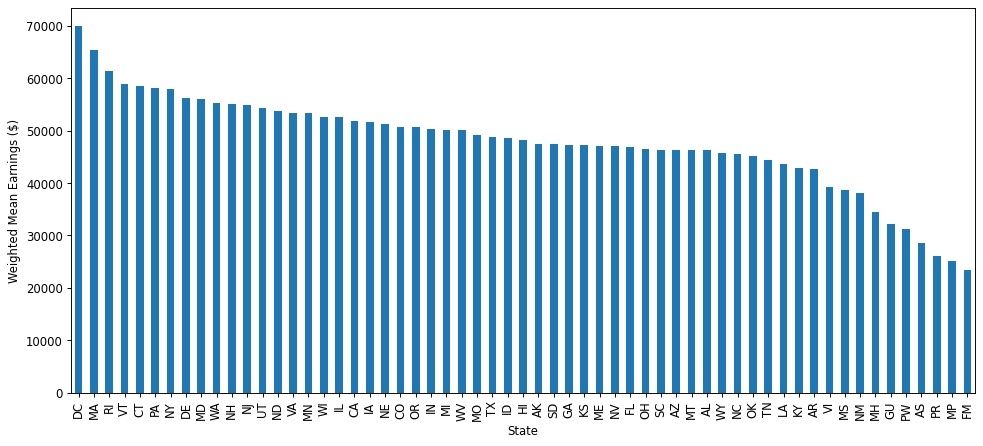

In [23]:
state_total = df_college_clean.groupby("State")["Undergraduates"].transform("sum")
df_college_clean["state_weight"] = df_college_clean["Undergraduates"] / state_total
df_college_clean["weighted_earnings"] = df_college_clean["state_weight"] * df_college_clean["Median Earnings"]

state_mean = df_college_clean.groupby("State")["weighted_earnings"].sum().sort_values(ascending=False)

state_mean.plot.bar(figsize=(14, 6), ylabel="Weighted Mean Earnings ($)")

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [24]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [25]:
gym_scores = df_gym.set_index(["Round", "Year", "Gymnast"]).loc[:, "Floor Exercise":"Pommelled Horse"]
gym_scores

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [26]:
gym_scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

Answer: Some gymnasts did not compete in all six events, so some scores are missing. Each event has a different number of missing scores. Since missing scores are not counted, the sample sizes are different and are not all 351.

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

Answer: NaN is more appropriate because the gymnast did not compete in the event. A 0 would count as an actual score and lower the mean. NaN shows that the score is missing.

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [27]:
gym_scores = gym_scores.replace(0, np.nan)

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [28]:
gym_scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


Answer: Horse Vault has the highest mean score, while Pommelled Horse has the lowest. Floor Exercise has the most variation in scores, while Rings has the least.

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [29]:
gym_scores.corr()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


Answer: Horse Vault and Rings have the highest correlation, while Floor Exercise and Pommelled Horse have the lowest correlation.

8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [30]:
gym_standardized = (gym_scores - gym_scores.mean()) / gym_scores.std()
gym_standardized

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [31]:
gym_ranked = gym_standardized.copy()
gym_ranked["Total"] = gym_standardized.sum(axis=1, min_count=6)
gym_ranked.sort_values("Total", ascending=False).reset_index()

,Round,Year,Gymnast,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Total
0,Final,2008,Yang Wei,0.750288,1.639221,1.500703,0.625432,2.610324,1.448331,8.574298
1,Qualification,2008,Yang Wei,0.869904,1.639221,0.685524,0.770020,2.172938,1.601796,7.739403
2,Final,2012,Kohei Uchimura,0.630671,1.343350,0.658351,1.420669,1.197566,1.234504,6.485111
3,Qualification,2008,Kim Dae-Eun,0.949648,1.118320,1.446357,0.480843,1.325501,0.885627,6.206298
4,Final,2016,Oleh Verniaiev,0.577243,0.545330,1.500703,0.649530,1.161481,1.712291,6.146577
...,...,...,...,...,...,...,...,...,...,...
346,Qualification,2008,Yordan Yovchev,NaN,NaN,NaN,NaN,2.227611,NaN,NaN
347,Qualification,2008,Oleksandr Vorobiov,NaN,NaN,NaN,NaN,2.200274,NaN,NaN
348,Qualification,2008,Mitja Petkovšek,NaN,NaN,1.527875,NaN,NaN,NaN,NaN
349,Qualification,2008,Epke Zonderland,NaN,NaN,NaN,1.565258,NaN,NaN,NaN


Answer: Yang Wei in the 2008 Final has the highest total standardized score, so he is the all-around standardized value champion.

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [32]:
gym_scores.groupby(level="Year").mean()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720250,15.841753,15.125758,14.563750,14.850532,14.248750
2012,14.495154,15.484308,14.663231,14.365922,14.441462,13.787172
2016,14.134667,14.496068,14.787083,14.246315,14.201514,14.051319
2020,13.841989,14.046398,14.242529,13.336919,13.453632,13.312341


Answer: The mean scores generally decrease over time, but some events increase between certain years. All six events have lower mean scores in 2020 than in 2008. This could be due to changes in scoring rules, judging, or the gymnasts competing in each year.

11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

/Users/shiqi/miniforge3/envs/datamining/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 28 rows containing non-finite values.


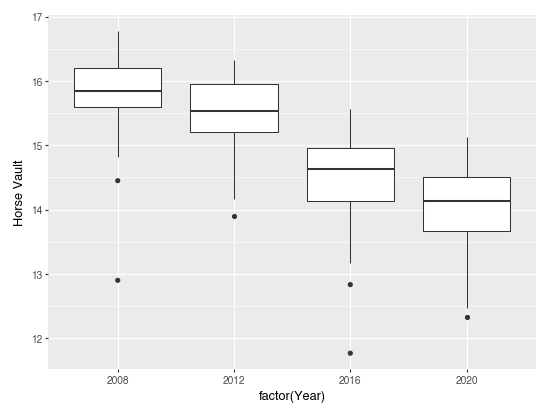

In [33]:
from plotnine import geom_boxplot

ggplot(gym_scores.reset_index(), aes(x="factor(Year)", y="Horse Vault")) + geom_boxplot()

Answer: Horse Vault scores generally decrease over time. The median scores are higher in 2008 and 2012 than in 2016 and 2020. The distributions overlap, and there are some unusually low scores.

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [34]:
year_mean = gym_scores.groupby(level="Year").transform("mean")
year_std = gym_scores.groupby(level="Year").transform("std")
gym_standardized_year = (gym_scores - year_mean) / year_std
gym_standardized_year

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.753096     0.027915   
                   David Belyavsky          0.753096     1.451057   
                   Fabian HambÃ¼chen        0.794185     0.620298   
                   John Orozco              0.835273     0.561594   
                   Kristian Thomas          1.084294     1.273164   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.098864    -0.076907   
                   Thomas Bouhail           0.365547     0.015192   
                   José Luis Fuentes       -0.415455    -1.089993   
                   Dzmitry Savitski        -0.758335     0.107290   
                   Chen Yibing                   NaN     0.107290   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.002995        1.708332  0.269011   
                   David Belyavsky         0.953577        0.569503 -0.128045   
                   Fabian HambÃ¼chen       0.953577        1.442985  0.550683   
                   John Orozco            -0.195024        1.025035  1.059729   
                   Kristian Thomas        -0.057251        1.138917  0.211319   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.896615       -0.385333 -1.098537   
                   Thomas Bouhail         -0.896615       -0.100954 -1.550593   
                   José Luis Fuentes       0.063005       -0.470647 -1.227696   
                   Dzmitry Savitski       -2.208096       -5.077583  0.580528   
                   Chen Yibing            -0.224881       -1.807227  2.324171   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.232874  
                   David Belyavsky           1.271729  
                   Fabian HambÃ¼chen         0.357497  
                   John Orozco               1.118595  
                   Kristian Thomas           0.395209  
...                                               ...  
Final         2008 Daniel Keatings           1.745577  
                   Thomas Bouhail           -1.020884  
                   José Luis Fuentes        -0.720182  
                   Dzmitry Savitski         -0.599901  
                   Chen Yibing              -0.599901  

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [35]:
gym_ranked_year = gym_standardized_year.copy()
gym_ranked_year["Total"] = gym_standardized_year.sum(axis=1, min_count=6)
gym_ranked_year.sort_values("Total", ascending=False).reset_index()

,Round,Year,Gymnast,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Total
0,Final,2016,Oleh Verniaiev,0.520383,1.475149,1.524323,0.534169,2.005141,1.554973,7.614139
1,Final,2012,Kohei Uchimura,0.753096,1.390574,0.991015,1.405403,1.512779,1.461432,7.514300
2,Qualification,2020,Daiki Hashimoto,1.196662,1.341947,1.007048,1.915265,0.443776,1.488590,7.393287
3,Final,2020,Daiki Hashimoto,1.382156,1.070152,1.007048,1.802342,0.085413,1.898201,7.245313
4,Qualification,2016,Oleh Verniaiev,0.404528,0.837441,1.600950,0.855432,1.822604,1.589606,7.110561
...,...,...,...,...,...,...,...,...,...,...
346,Qualification,2008,Yordan Yovchev,NaN,NaN,NaN,NaN,1.839826,NaN,NaN
347,Qualification,2008,Oleksandr Vorobiov,NaN,NaN,NaN,NaN,1.807536,NaN,NaN
348,Qualification,2008,Mitja Petkovšek,NaN,NaN,1.278524,NaN,NaN,NaN,NaN
349,Qualification,2008,Epke Zonderland,NaN,NaN,NaN,1.349377,NaN,NaN,NaN


Answer: Oleh Verniaiev in the 2016 Final has the highest total standardized score, followed by Kohei Uchimura in the 2012 Final and Daiki Hashimoto in the 2020 qualification.